# Study 8 (Supplementary) - Operational Significance of the Effects

Reviewer point: the AUROC gains are small, so translate them into terms a deployment team cares about.
This notebook reports, for the twin, the gradient boosting model, and the stacked hybrid, under pollutant
dropout:

1. **Detection rate (recall) at a fixed false-alarm rate.** The decision threshold is set so that the
   false-positive rate on non-onset intervals equals a target (5 percent and 10 percent). Recall at that
   operating point is the fraction of onset intervals that would be flagged. This is what an operator
   experiences: at an accepted false-alarm budget, how many true onsets are caught.
2. **Reduction in missed onset intervals.** From recall, the relative reduction in missed onsets of one
   model over another, which converts a small AUROC gain into an operational quantity.

Task and data match the main study: Nordic PM2.5 + ERA5, 6 h steps, onset of a WHO-15 exceedance within
24 h, interleaved even/odd-month holdout. Nothing is executed in the repository copy; run it to produce
the numbers, and read them into Section 3 of the paper. Wording note: these are onset-labelled 6 h
intervals, not distinct episodes.

In [1]:
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
np.random.seed(0)
OUT=Path("../outputs/study8_operational"); OUT.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":150,"font.size":11,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
STEP=6; H=4; TAU=15.0
pm=pd.read_csv("../data/openaq_regional/regional_pm25.csv"); pm["datetime"]=pd.to_datetime(pm["datetime"],utc=True)
pm["name"]=pm.station.str.split("::").str[1]; pm=pm.dropna(subset=["value"]); pm=pm[(pm.value>=0)&(pm.value<1500)]
met=pd.read_csv("../data/era5/era5_regional.csv",usecols=["datetime","station","wind_speed","blh","t2m"])
met["datetime"]=pd.to_datetime(met["datetime"],utc=True); met=met.rename(columns={"station":"name"})
yrs=pm.groupby("station")["datetime"].agg(lambda s:(s.max()-s.min()).days/365.25); pm=pm[pm.station.isin(yrs[yrs>=2].index)].copy()
print("stations",pm.station.nunique())

stations 21


## Model definitions

The fuller multimodal twin (with recalibration), the gradient boosting baseline, and the stacked hybrid
trained with dropout augmentation, reproduced exactly as in the main study.

In [2]:
K=5; LEV=[i/(K-1) for i in range(K)]; SDL=[1.0+0.5*l for l in LEV]; LOGC=0.5*math.log(2*math.pi); LGC=[-LOGC-math.log(s) for s in SDL]
def lgv(z): return [LGC[k]-0.5*((z-2.0*LEV[k])/SDL[k])**2 for k in range(K)]
WPM,WW,WB,WT=1.0,0.5,0.5,0.4
def twin(zpm,zw,zb,zt):
    logb=[-3*k for k in range(K)]; m=max(logb); ss=sum(math.exp(x-m) for x in logb); logb=[x-m-math.log(ss) for x in logb]
    risk=np.empty(len(zpm)); ent=np.empty(len(zpm))
    for t in range(len(zpm)):
        mb=max(logb); b=[math.exp(x-mb) for x in logb]; sb=sum(b); b=[x/sb for x in b]
        el=sum(b[k]*LEV[k] for k in range(K)); up=0.25; pdn=0.05 if el>0.4 else 0.15; bp=[0.0]*K
        for k in range(K):
            u=up if k<K-1 else 0.0; d=pdn if k>0 else 0.0; bp[k]+=b[k]*(1-u-d)
            if k<K-1: bp[k+1]+=b[k]*u
            if k>0: bp[k-1]+=b[k]*d
        logbp=[math.log(x+1e-12) for x in bp]
        for zv,w,inv in [(zpm,WPM,1),(zw,WW,-1),(zb,WB,-1),(zt,WT,-1)]:
            if not math.isnan(zv[t]):
                lv=lgv(inv*zv[t]); logbp=[logbp[k]+w*lv[k] for k in range(K)]
        m2=max(logbp); s2=math.log(sum(math.exp(x-m2) for x in logbp)); logb=[x-m2-s2 for x in logbp]
        eb=[math.exp(x) for x in logb]; risk[t]=sum(eb[k]*LEV[k] for k in range(K)); ent[t]=-sum(p*math.log(p+1e-12) for p in eb)
    return risk,ent
def sig(z): return 1/(1+np.exp(-np.clip(z,-30,30)))
def fitlog(X,y,ep=2500,lr=.3,l2=1.):
    X=np.asarray(X,float);mu=X.mean(0);sd=X.std(0)+1e-9;Xs=(X-mu)/sd;Xb=np.hstack([np.ones((len(Xs),1)),Xs]);w=np.zeros(Xb.shape[1])
    for _ in range(ep): p=sig(Xb@w);g=Xb.T@(p-y)/len(y);g[1:]+=l2/len(y)*w[1:];w-=lr*g
    return (w,mu,sd)
def pl(m,X): w,mu,sd=m;Xs=(np.asarray(X,float)-mu)/sd;return sig(np.hstack([np.ones((len(Xs),1)),Xs])@w)
def platt_fit(x,y,ep=3000,lr=.3):
    x=np.asarray(x,float);mu,sd=x.mean(),x.std()+1e-9;xs=(x-mu)/sd;w=0.;bi=0.
    for _ in range(ep): p=1/(1+np.exp(-(w*xs+bi)));w-=lr*np.mean((p-y)*xs);bi-=lr*np.mean(p-y)
    return lambda z:1/(1+np.exp(-(w*((np.asarray(z,float)-mu)/sd)+bi)))

FEATS=["zpm","zpm_l1","zpm_l2","zpm_tr","zwind","zblh","ztemp","hour_sin","hour_cos","doy_sin","doy_cos"]
ST={}; rows=[]
for st,g in pm.groupby("station"):
    name=g["name"].iloc[0]
    s=g.set_index("datetime").value.resample(f"{STEP}h").mean()
    mg=met[met.name==name].set_index("datetime")[["wind_speed","blh","t2m"]].resample(f"{STEP}h").mean()
    idx=s.index; A=pd.DataFrame({"pm":s}).join(mg).reindex(idx); tm=(idx.month%2==0)
    def z(col,log=False):
        v=np.log1p(np.clip(A[col].to_numpy(),0,None)) if log else A[col].to_numpy()
        mu,sd=np.nanmean(v[tm]),np.nanstd(v[tm])+1e-9; return (v-mu)/sd
    zpm=z("pm",log=True); zw=z("wind_speed"); zb=z("blh"); zt=z("t2m"); risk,ent=twin(zpm,zw,zb,zt)
    v=A["pm"].to_numpy(); hr=idx.hour.to_numpy(); doy=idx.dayofyear.to_numpy()
    ST[st]=dict(zpm=zpm,zw=zw,zb=zb,zt=zt,v=v,tm=tm,hr=hr,doy=doy)
    g2=lambda a:(a if not np.isnan(a) else 0.0)
    for t in range(2,len(v)-H):
        if np.isnan(v[t]) or v[t]>=TAU: continue
        fut=v[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        rows.append(dict(station=st,ti=t,split=("train" if tm[t] else "test"),label=int(np.nanmax(fut)>=TAU),
            zpm=g2(zpm[t]),zpm_l1=g2(zpm[t-1]),zpm_l2=g2(zpm[t-2]),zpm_tr=g2(zpm[t]-zpm[t-2]),
            zwind=g2(zw[t]),zblh=g2(zb[t]),ztemp=g2(zt[t]),
            hour_sin=math.sin(2*math.pi*hr[t]/24),hour_cos=math.cos(2*math.pi*hr[t]/24),
            doy_sin=math.sin(2*math.pi*doy[t]/365),doy_cos=math.cos(2*math.pi*doy[t]/365),risk=risk[t],ent=ent[t]))
S=pd.DataFrame(rows); tr,te=S[S.split=="train"],S[S.split=="test"]; ytr,yte=tr.label.values,te.label.values
gbm=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,max_depth=4,l2_regularization=1.0,random_state=0).fit(tr[FEATS].values,ytr)
ftw=platt_fit(tr.risk.values,ytr)
# stacked hybrid with dropout augmentation
def station_rows(st,pdrop,seed,split):
    d=ST[st]; rng=np.random.default_rng(seed); zpm=d["zpm"]
    miss=(rng.random(len(zpm))<pdrop) if pdrop>0 else np.zeros(len(zpm),bool)
    zpm_m=zpm.copy(); zpm_m[miss]=np.nan; risk_m,ent_m=twin(zpm_m,d["zw"],d["zb"],d["zt"])
    zff=zpm.copy()
    for i in range(len(zff)):
        if miss[i]: zff[i]=zff[i-1] if i>0 else zff[i]
    v=d["v"]; tm=d["tm"]; hr=d["hr"]; doy=d["doy"]; g2=lambda a:(a if not np.isnan(a) else 0.0); want=(split=="train")
    X=[];mm=[];TW=[];EN=[];Y=[]
    for t in range(2,len(v)-H):
        if np.isnan(v[t]) or v[t]>=TAU or (tm[t]!=want): continue
        fut=v[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        X.append([g2(zff[t]),g2(zff[t-1]),g2(zff[t-2]),g2(zff[t]-zff[t-2]),g2(d["zw"][t]),g2(d["zb"][t]),g2(d["zt"][t]),
                  math.sin(2*math.pi*hr[t]/24),math.cos(2*math.pi*hr[t]/24),math.sin(2*math.pi*doy[t]/365),math.cos(2*math.pi*doy[t]/365)])
        mm.append(1.0 if miss[t] else 0.0); TW.append(risk_m[t]); EN.append(ent_m[t]); Y.append(int(np.nanmax(fut)>=TAU))
    return np.array(X),np.array(mm),np.array(TW),np.array(EN),np.array(Y)
def meta_features(pg,pt,miss,ent): return np.column_stack([pg,pt,miss,ent,pg*(1-miss),pt*miss])
Xtr=[];Ytr=[]
for lvl,sd in [(0.0,0),(0.85,2)]:
    for st in ST:
        X,mm,TW,EN,Y=station_rows(st,lvl,sd,"train")
        if len(Y)==0: continue
        Xtr.append(meta_features(gbm.predict_proba(X)[:,1],ftw(TW),mm,EN)); Ytr.append(Y)
stk=fitlog(np.vstack(Xtr),np.concatenate(Ytr))
print("panel + models ready | test rows",len(te),"| onset prevalence",round(te.label.mean(),3))

panel + models ready | test rows 48208 | onset prevalence 0.07


## Operational metric: detection rate at a fixed false-alarm rate

The decision threshold is set on the non-onset (true-negative) test intervals so that the false-alarm rate
equals the target. Recall at that threshold is the detection rate. Reported for the gradient boosting
model, the twin, and the stacked hybrid, across pollutant dropout.

In [3]:
def recall_at_fpr(scores,y,fpr):
    scores=np.asarray(scores,float); y=np.asarray(y,int)
    neg=scores[y==0]; thr=np.quantile(neg,1-fpr)   # fraction fpr of negatives above thr
    pos=scores[y==1]; return float((pos>=thr).mean())

def eval_ops(pdrop,seed,fpr):
    PG=[];PT=[];MM=[];EN=[];Y=[]
    for st in ST:
        X,mm,TW,en,y=station_rows(st,pdrop,seed,"test")
        if len(y)==0: continue
        PG.append(gbm.predict_proba(X)[:,1]);PT.append(ftw(TW));MM.append(mm);EN.append(en);Y.append(y)
    PG=np.concatenate(PG);PT=np.concatenate(PT);MM=np.concatenate(MM);EN=np.concatenate(EN);Y=np.concatenate(Y)
    stkp=pl(stk,meta_features(PG,PT,MM,EN))
    return {"gbm":recall_at_fpr(PG,Y,fpr),"twin":recall_at_fpr(PT,Y,fpr),
            "hybrid":recall_at_fpr(stkp,Y,fpr),"n_pos":int((Y==1).sum())}

for fpr in [0.05,0.10]:
    print(f"\n=== detection rate (recall) at false-alarm rate {int(fpr*100)}% ===")
    print("dropout | GBM   | twin  | hybrid | hybrid-GBM | fewer missed vs GBM")
    for p in [0.0,0.4,0.7,0.85]:
        seeds=[0] if p==0 else [0,1]
        r={k:np.mean([eval_ops(p,s,fpr)[k] for s in seeds]) for k in ["gbm","twin","hybrid"]}
        red = (r["hybrid"]-r["gbm"])/(1-r["gbm"]) if r["gbm"]<1 else 0.0  # relative reduction in missed onsets
        print(f"  {int(p*100):3d}%   | {r['gbm']:.3f} | {r['twin']:.3f} | {r['hybrid']:.3f} |  {r['hybrid']-r['gbm']:+.3f}   | {red*100:+.1f}%")


=== detection rate (recall) at false-alarm rate 5% ===
dropout | GBM   | twin  | hybrid | hybrid-GBM | fewer missed vs GBM
    0%   | 0.299 | 0.288 | 0.281 |  -0.018   | -2.5%
   40%   | 0.272 | 0.262 | 0.270 |  -0.003   | -0.3%
   70%   | 0.234 | 0.231 | 0.237 |  +0.003   | +0.4%
   85%   | 0.205 | 0.218 | 0.219 |  +0.014   | +1.7%

=== detection rate (recall) at false-alarm rate 10% ===
dropout | GBM   | twin  | hybrid | hybrid-GBM | fewer missed vs GBM
    0%   | 0.464 | 0.450 | 0.448 |  -0.016   | -2.9%
   40%   | 0.427 | 0.410 | 0.425 |  -0.001   | -0.3%
   70%   | 0.373 | 0.375 | 0.386 |  +0.013   | +2.0%
   85%   | 0.334 | 0.349 | 0.349 |  +0.015   | +2.3%


## Translating to missed onset intervals

At a fixed 10 percent false-alarm rate, the number of missed onset intervals is $(1-\text{recall})$ times
the onset count. The relative reduction in missed onsets of the hybrid over the gradient boosting model
converts the small AUROC gain into an operational figure. The cell below prints, per dropout level, the
onset count, missed by each model, and the reduction.

In [4]:
fpr=0.10
print("dropout | onsets | missed GBM | missed hybrid | reduction")
for p in [0.0,0.4,0.7,0.85]:
    seeds=[0] if p==0 else [0,1]
    res=[eval_ops(p,s,fpr) for s in seeds]
    npos=int(np.mean([r["n_pos"] for r in res]))
    rg=np.mean([r["gbm"] for r in res]); rh=np.mean([r["hybrid"] for r in res])
    mg=(1-rg)*npos; mh=(1-rh)*npos
    print(f"  {int(p*100):3d}%   | {npos:5d}  |   {mg:6.0f}   |    {mh:6.0f}     | {mg-mh:5.0f} ({(mg-mh)/mg*100:.1f}%)")
print("\nNote: counts are onset-labelled 6 h intervals in the test partition, not distinct episodes.")

dropout | onsets | missed GBM | missed hybrid | reduction
    0%   |  3368  |     1805   |      1858     |   -53 (-2.9%)
   40%   |  3368  |     1931   |      1935     |    -5 (-0.3%)
   70%   |  3368  |     2112   |      2070     |    42 (2.0%)
   85%   |  3368  |     2243   |      2192     |    50 (2.3%)

Note: counts are onset-labelled 6 h intervals in the test partition, not distinct episodes.


## Figure: detection rate at 10 percent false-alarm rate vs dropout

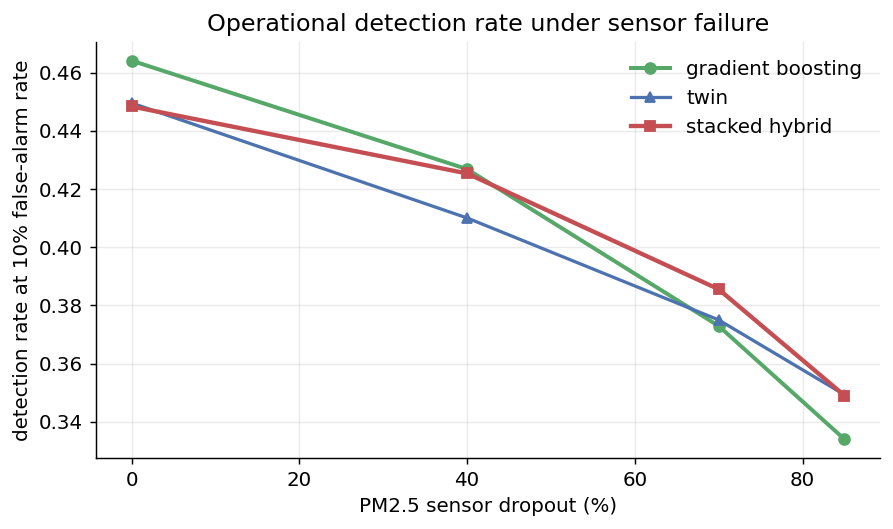

In [5]:
fpr=0.10; ps=[0.0,0.4,0.7,0.85]; G=[];T=[];Hh=[]
for p in ps:
    seeds=[0] if p==0 else [0,1]
    G.append(np.mean([eval_ops(p,s,fpr)["gbm"] for s in seeds]))
    T.append(np.mean([eval_ops(p,s,fpr)["twin"] for s in seeds]))
    Hh.append(np.mean([eval_ops(p,s,fpr)["hybrid"] for s in seeds]))
fig,ax=plt.subplots(figsize=(7,4.2)); xp=[p*100 for p in ps]
ax.plot(xp,G,"-o",color="#55A868",lw=2.2,label="gradient boosting")
ax.plot(xp,T,"-^",color="#4C72B0",lw=1.8,label="twin")
ax.plot(xp,Hh,"-s",color="#C44E52",lw=2.4,label="stacked hybrid")
ax.set_xlabel("PM2.5 sensor dropout (%)"); ax.set_ylabel("detection rate at 10% false-alarm rate")
ax.set_title("Operational detection rate under sensor failure"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(OUT/"fig1_detection_at_fpr.png",bbox_inches="tight"); plt.show()